https://www.kaggle.com/datasets/kaggle/sf-salaries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


In [34]:
df = pd.read_csv("sf_salaries_cleaned.csv")

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148624 entries, 0 to 148623
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   EmployeeName      148624 non-null  object 
 1   JobTitle          148624 non-null  object 
 2   BasePay           148624 non-null  float64
 3   OvertimePay       148624 non-null  float64
 4   OtherPay          148624 non-null  float64
 5   Benefits          148624 non-null  float64
 6   TotalPay          148624 non-null  float64
 7   TotalPayBenefits  148624 non-null  float64
 8   Year              148624 non-null  int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 10.2+ MB


In [36]:
df.isna().sum()

EmployeeName        0
JobTitle            0
BasePay             0
OvertimePay         0
OtherPay            0
Benefits            0
TotalPay            0
TotalPayBenefits    0
Year                0
dtype: int64

In [37]:
df.describe()

,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year
count,148624.000000,148624.000000,148624.000000,148624.000000,148624.000000,148624.000000,148624.000000
mean,66067.062342,5066.946133,3649.405605,18928.052727,74783.414081,93711.466808,2012.522406
std,42880.769285,11455.186420,8057.161986,17164.905825,50510.932452,62785.758548,1.117452
min,-166.010000,-0.010000,-7058.590000,-33.890000,-618.130000,-618.130000,2011.000000
25%,32840.870000,0.000000,0.000000,0.000000,36191.340000,44129.167500,2012.000000
50%,64872.330000,0.000000,812.290000,23236.325000,71432.885000,92417.345000,2013.000000
75%,94611.002500,4658.937500,4237.620000,33470.220000,105848.182500,132884.875000,2014.000000
max,319275.010000,245131.880000,400184.250000,96570.660000,567595.430000,567595.430000,2014.000000


### Total Pay Distribution

In [38]:
df.columns

Index(['EmployeeName', 'JobTitle', 'BasePay', 'OvertimePay', 'OtherPay',
       'Benefits', 'TotalPay', 'TotalPayBenefits', 'Year'],
      dtype='object')

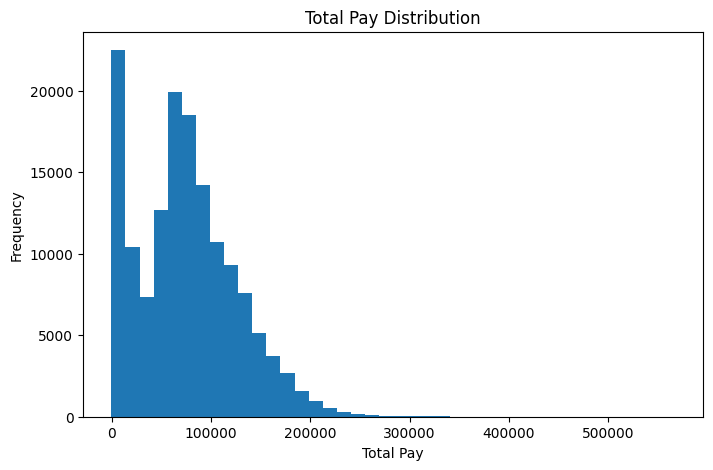

In [39]:
plt.figure(figsize= (8,5))
plt.hist(df["TotalPay"], bins = 40)
plt.title("Total Pay Distribution")
plt.xlabel("Total Pay")
plt.ylabel("Frequency")
plt.show()

- The distribution of **Total Pay** is positively (right) skewed.
- Most employees earn less than **$100,000**.
- Only a small number of employees receive exceptionally high salaries exceeding **$200,000**.
- These high-value observations indicate the presence of **outliers**, which may influence summary statistics such as the **mean**.


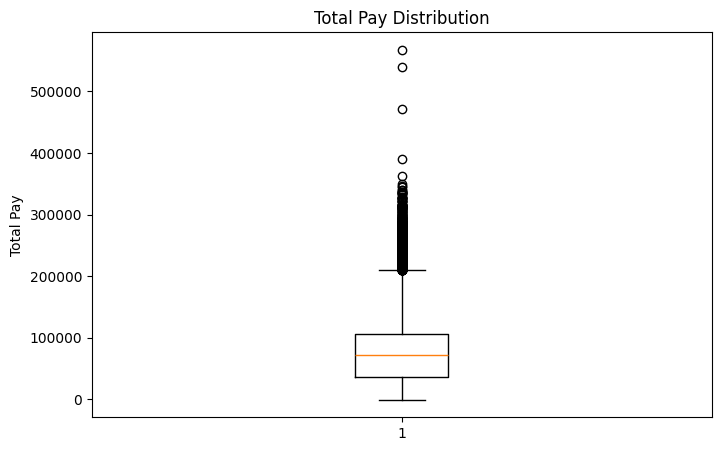

In [40]:
plt.figure(figsize=(8,5))
plt.boxplot(df["TotalPay"])
plt.title("Total Pay Distribution")
plt.ylabel("Total Pay")
plt.show()

- The median **Total Pay** is approximately **$70,000**.
- The middle 50% of employees earn between approximately **$35,000** and **$105,000**.
- A large number of **outliers** appear above **$210,000**, with some salaries exceeding **$550,000**.
- The concentration of high-value outliers indicates that the distribution is **positively (right) skewed**, meaning a small number of employees earn significantly higher salaries than the majority.

### Base Pay Distribution

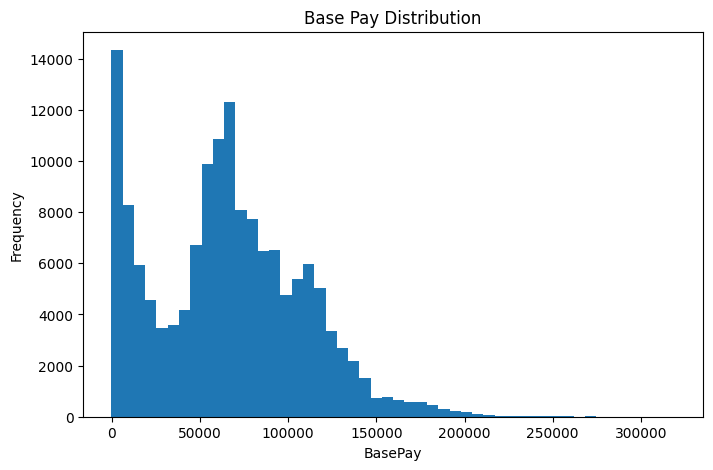

In [41]:
plt.figure(figsize= (8,5))
plt.hist(df["BasePay"], bins = 50)
plt.title("Base Pay Distribution")
plt.xlabel("BasePay")
plt.ylabel("Frequency")
plt.show()

- The distribution of **Base Pay** is positively (right) skewed.
- Most employees have a base salary between **$50,000** and **$100,000**.
- A noticeable number of employees have **very low or zero Base Pay**, which may indicate part-time positions, overtime-based compensation, or records that require further investigation.
- Only a small number of employees earn exceptionally high base salaries, creating a long right tail in the distribution.

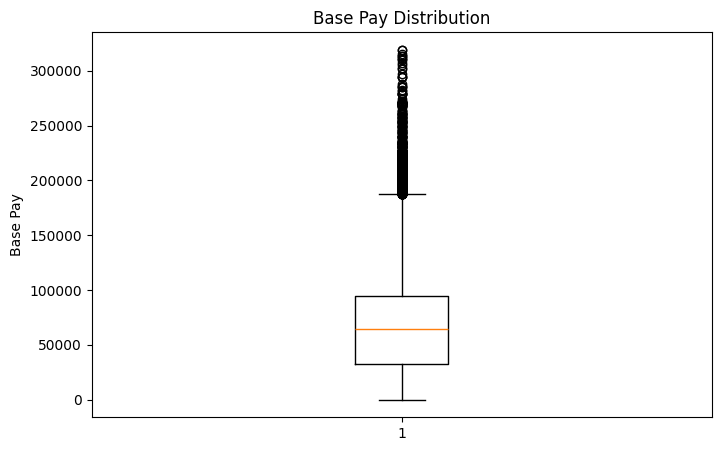

In [42]:
plt.figure(figsize=(8,5))
plt.boxplot(df["BasePay"])
plt.title("Base Pay Distribution")
plt.ylabel("Base Pay")
plt.show()

- The median **Base Pay** is approximately **$65,000**.
- The middle 50% of employees earn between approximately **$30,000** and **$95,000**.
- A large number of outliers appear above **$185,000**, with the highest base salaries exceeding **$320,000**.
- The presence of many high-value outliers indicates that the **Base Pay** distribution is positively (right) skewed.
- Some employees have very low or zero base salaries, suggesting records that may require further investigation.

### Top 10 jobs by average Total Pay

In [43]:
top_jobs = df.groupby("JobTitle")["TotalPay"].mean().sort_values(ascending= 0).head(10)

In [44]:
top_jobs

JobTitle
GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY    399211.275000
Chief Investment Officer                          339653.700000
Chief of Police                                   329183.646667
Chief, Fire Department                            325971.683333
DEPUTY DIRECTOR OF INVESTMENTS                    307899.460000
CHIEF OF DEPARTMENT, (FIRE DEPARTMENT)            302377.730000
Gen Mgr, Public Trnsp Dept                        297769.413333
Asst Chf of Dept (Fire Dept)                      281763.483889
DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)      279359.560000
Dep Dir for Investments, Ret                      278592.545000
Name: TotalPay, dtype: float64

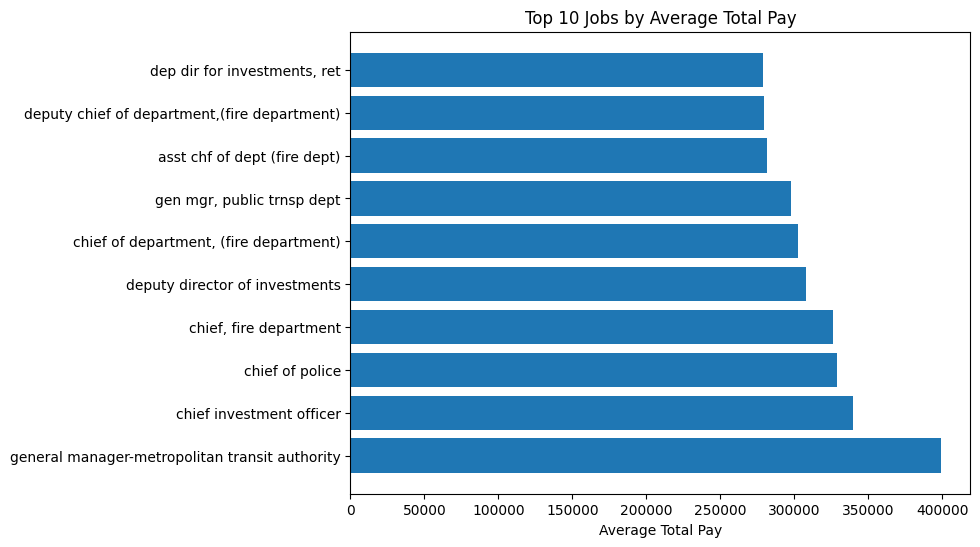

In [45]:
plt.figure(figsize=(8,6))
plt.barh(top_jobs.index.str.lower(), top_jobs.values)
plt.xlabel("Average Total Pay")
plt.title("Top 10 Jobs by Average Total Pay")
plt.show()

- **General Manager – Metropolitan Transit Authority** has the highest average **Total Pay**, reaching approximately **$400,000**.
- Most of the top-paying positions are executive and leadership roles, including department chiefs, directors, and managers.
- The average Total Pay for the top 10 job titles ranges from approximately **$280,000** to **$400,000**.
- The noticeable gap between the highest-paying position and the remaining job titles highlights the premium compensation associated with top executive roles.

### Most frequently used jobs

In [46]:
most_jobs = df["JobTitle"].value_counts().head(10)
most_jobs

JobTitle
Transit Operator                7036
Special Nurse                   4389
Registered Nurse                3736
Public Svc Aide-Public Works    2518
Police Officer 3                2421
Custodian                       2415
TRANSIT OPERATOR                2387
Firefighter                     2359
Recreation Leader               1971
Patient Care Assistant          1945
Name: count, dtype: int64

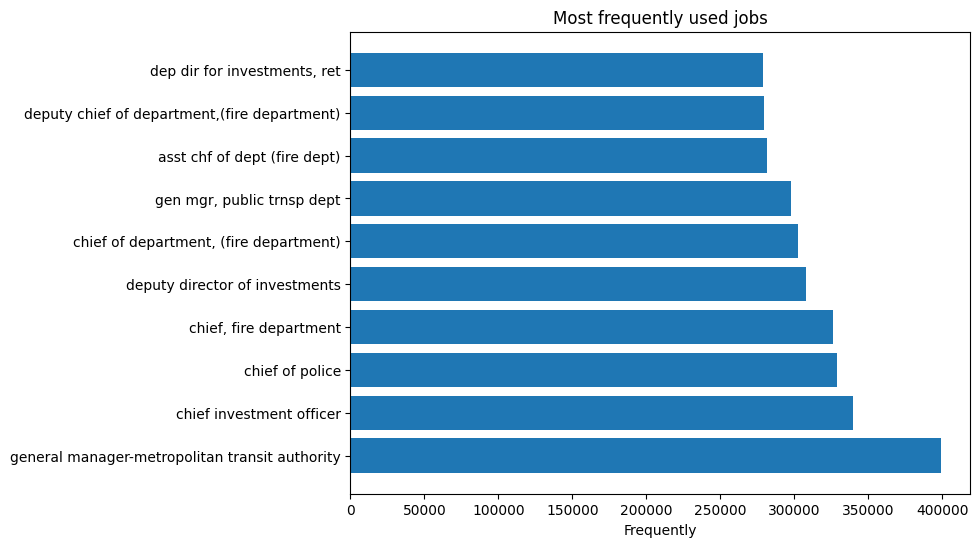

In [47]:
plt.figure(figsize=(8,6))
plt.barh(top_jobs.index.str.lower(), top_jobs.values)
plt.xlabel("Frequently")
plt.title("Most frequently used jobs")
plt.show()

### Average salary per year

In [48]:
mean_salary = df.groupby("Year")["TotalPay"].mean()

In [49]:
max_year = mean_salary.idxmax()
max_salary = mean_salary.max()

In [50]:
print(max_year, max_salary)

2013 77611.44314205181


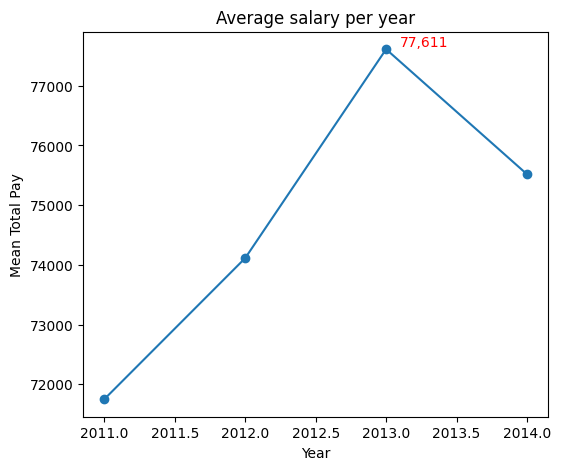

In [51]:
plt.figure(figsize= (6,5))
plt.plot(mean_salary, marker='o')

plt.text(max_year +0.1 ,
         max_salary + 40,
         f'{max_salary:,.0f}',
         ha='left',
         color='red',
         fontsize=10)
plt.title("Average salary per year")
plt.xlabel("Year")
plt.ylabel("Mean Total Pay")
plt.show()

1. The average salary showed a steady upward trend from **2011 to 2013**.
2. The average salary reached its **highest level in 2013**.
3. Although the average salary declined in **2014**, it remained **higher than the averages recorded in 2011 and 2012**.
4. The **largest year-over-year increase** in the average salary occurred between **2012 and 2013**.

### Top 3 Job Titles by Average Total Pay (2011–2014)

In [52]:
top10_jobs = df.groupby(["Year","JobTitle"])["TotalPay"].mean().reset_index().sort_values(["Year","TotalPay"],ascending=[True, False]).groupby("Year").head(3)

In [53]:
top10_jobs

,Year,JobTitle,TotalPay
395,2011,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,399211.275
290,2011,DEPUTY DIRECTOR OF INVESTMENTS,307899.460
172,2011,"CHIEF OF DEPARTMENT, (FIRE DEPARTMENT)",302377.730
1231,2012,Chief of Police,321552.110
1232,2012,"Chief, Fire Department",314759.600
1450,2012,"Gen Mgr, Public Trnsp Dept",294000.170
2278,2013,Chief of Police,339282.070
2279,2013,"Chief, Fire Department",336922.010
2377,2013,"Dep Dir for Investments, Ret",315572.010
3318,2014,Chief Investment Officer,339653.700


In [54]:
top10_jobs_pivot = top10_jobs.pivot(index = "Year" , columns="JobTitle" , values= "TotalPay").fillna(0)
top10_jobs_pivot

JobTitle,"CHIEF OF DEPARTMENT, (FIRE DEPARTMENT)",Chief Investment Officer,Chief of Police,"Chief, Fire Department",DEPUTY DIRECTOR OF INVESTMENTS,"Dep Dir for Investments, Ret",GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,"Gen Mgr, Public Trnsp Dept"
Year,,,,,,,,
2011,302377.73,0.0,0.00,0.00,307899.46,0.00,399211.275,0.00
2012,0.00,0.0,321552.11,314759.60,0.00,0.00,0.000,294000.17
2013,0.00,0.0,339282.07,336922.01,0.00,315572.01,0.000,0.00
2014,0.00,339653.7,326716.76,326233.44,0.00,0.00,0.000,0.00


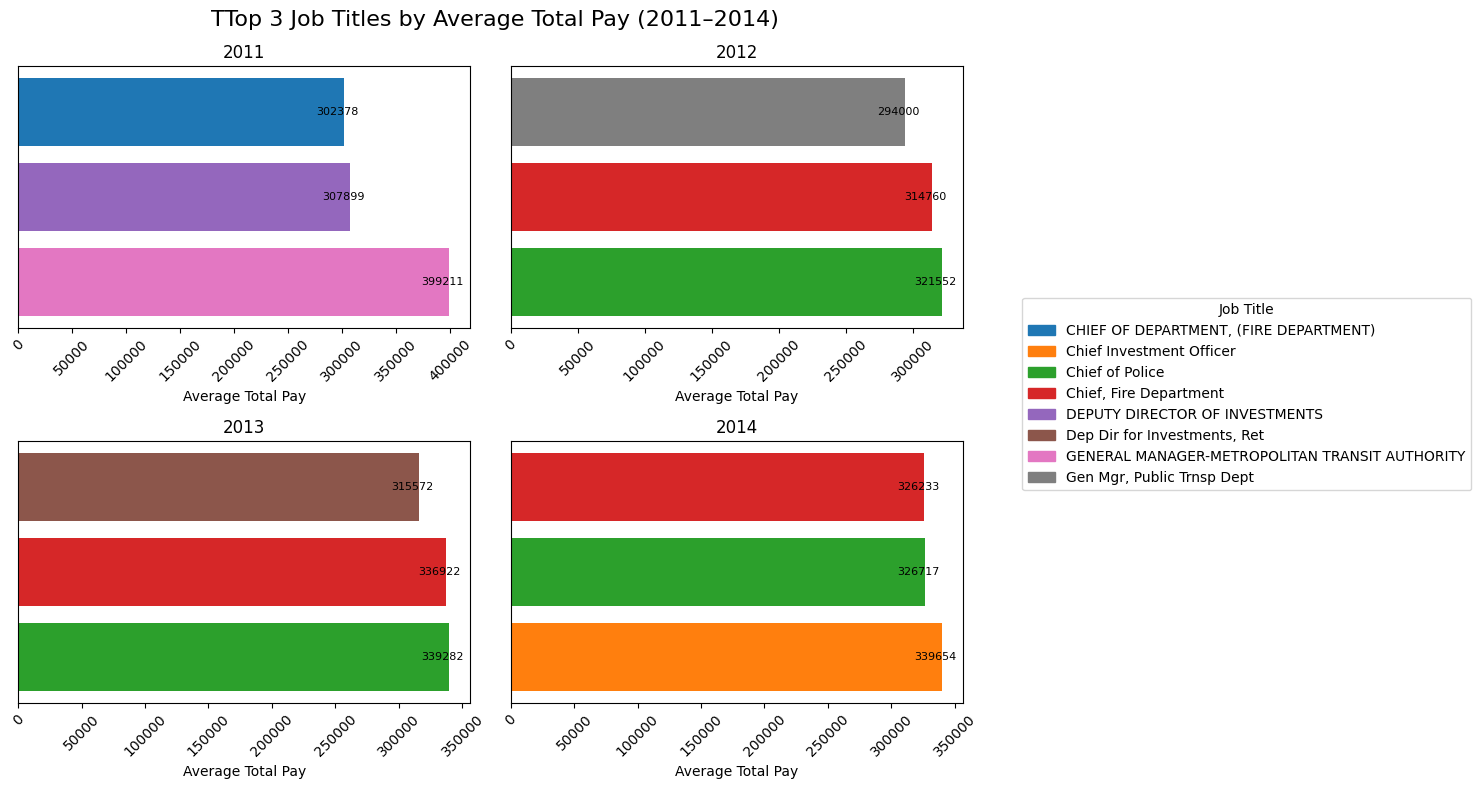

In [55]:
years = sorted(top10_jobs["Year"].unique())
jobs = sorted(top10_jobs["JobTitle"].unique())
colors = plt.cm.tab10(range(len(jobs)))
job_colors = dict(zip(jobs, colors))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, year in zip(axes, years):
    temp = top10_jobs[top10_jobs["Year"] == year]
    bar_colors = [job_colors[job] for job in temp["JobTitle"]]
    bars = ax.barh(temp["JobTitle"],
        temp["TotalPay"],
        color=bar_colors)
    ax.invert_yaxis()
    ax.set_title(str(year))
    ax.set_yticks([])
    ax.set_xlabel("Average Total Pay")
    ax.tick_params(axis='x', rotation=45)
    ax.invert_yaxis()
    ax.bar_label(bars, fmt="%.0f", fontsize=8, padding= -20)

handles = [
    Patch(color=job_colors[job], label=job)
    for job in jobs
]
fig.legend(
    handles=handles,
    title="Job Title",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)
plt.suptitle("Top 3 Job Titles by Average Total Pay (2011–2014)", fontsize=16)
plt.tight_layout()
plt.show()


- The top three job titles with the highest **Average Total Pay** in **2011** are completely different from those in the following years (2012–2014), indicating a shift in the highest-paying job titles over the analyzed period.

- The **Chief of Police** position ranked third among the highest-paying job titles in terms of average total pay in **2012** and **2013**, then moved up to second place in **2014**, reflecting an increase in its average total pay relative to the other top-paying positions.

- The **Chief, Fire Department** position remained among the top three highest-paying job titles in **2013** and **2014**, demonstrating consistent ranking among the highest-paid positions, although it moved from second place in 2013 to third place in 2014.

- **2011** shows the largest gap between the highest-paid job title and the second-ranked position, with a difference of approximately **$90,000** in average total pay.

- The gap between the top three highest-paying job titles became noticeably smaller after **2011**. In **2012**, **2013**, and **2014**, the average total pay of the top three job titles was much closer than in 2011.

- The highest average salaries remained relatively stable from **2012** to **2014**, ranging from approximately **$294,000** to **$340,000**. In contrast, **2011** included a job title with an average total pay exceeding **$390,000**, making it stand out from the other years.

- Several job titles appeared in the top three only once during the analyzed period, including:
  - **GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY**
  - **DEPUTY DIRECTOR OF INVESTMENTS**
  - **Chief Investment Officer**

- In contrast, some job titles consistently appeared among the top three highest-paying positions across multiple years, including:
  - **Chief of Police**
  - **Chief, Fire Department**

This indicates that these positions maintained relatively high average salaries throughout the analyzed period.


### Top 3 Job Titles by Employee Count (2011–2014)

In [56]:
df.columns

Index(['EmployeeName', 'JobTitle', 'BasePay', 'OvertimePay', 'OtherPay',
       'Benefits', 'TotalPay', 'TotalPayBenefits', 'Year'],
      dtype='object')

In [68]:
top_jobs_emp_count = (
    df.groupby(["Year", "JobTitle"])
      .size()
      .reset_index(name="EmployeeCount")
      .sort_values(["Year", "EmployeeCount"], ascending=[True, False])
      .groupby("Year")
      .head(3)
)

top_jobs_emp_count

,Year,JobTitle,EmployeeCount
983,2011,TRANSIT OPERATOR,2387
909,2011,SPECIAL NURSE,1402
750,2011,REGISTERED NURSE,1219
2036,2012,Transit Operator,2262
1930,2012,Special Nurse,1466
1801,2012,Registered Nurse,1271
3085,2013,Transit Operator,2295
2979,2013,Special Nurse,1445
2855,2013,Registered Nurse,1231
4078,2014,Transit Operator,2479


In [70]:
top_jobs_emp_count_pivot = top_jobs_emp_count.pivot(
    columns="JobTitle",
    index="Year",
    values = "EmployeeCount"
).fillna(0)
top_jobs_emp_count_pivot

JobTitle,REGISTERED NURSE,Registered Nurse,SPECIAL NURSE,Special Nurse,TRANSIT OPERATOR,Transit Operator
Year,,,,,,
2011,1219.0,0.0,1402.0,0.0,2387.0,0.0
2012,0.0,1271.0,0.0,1466.0,0.0,2262.0
2013,0.0,1231.0,0.0,1445.0,0.0,2295.0
2014,0.0,1234.0,0.0,1478.0,0.0,2479.0


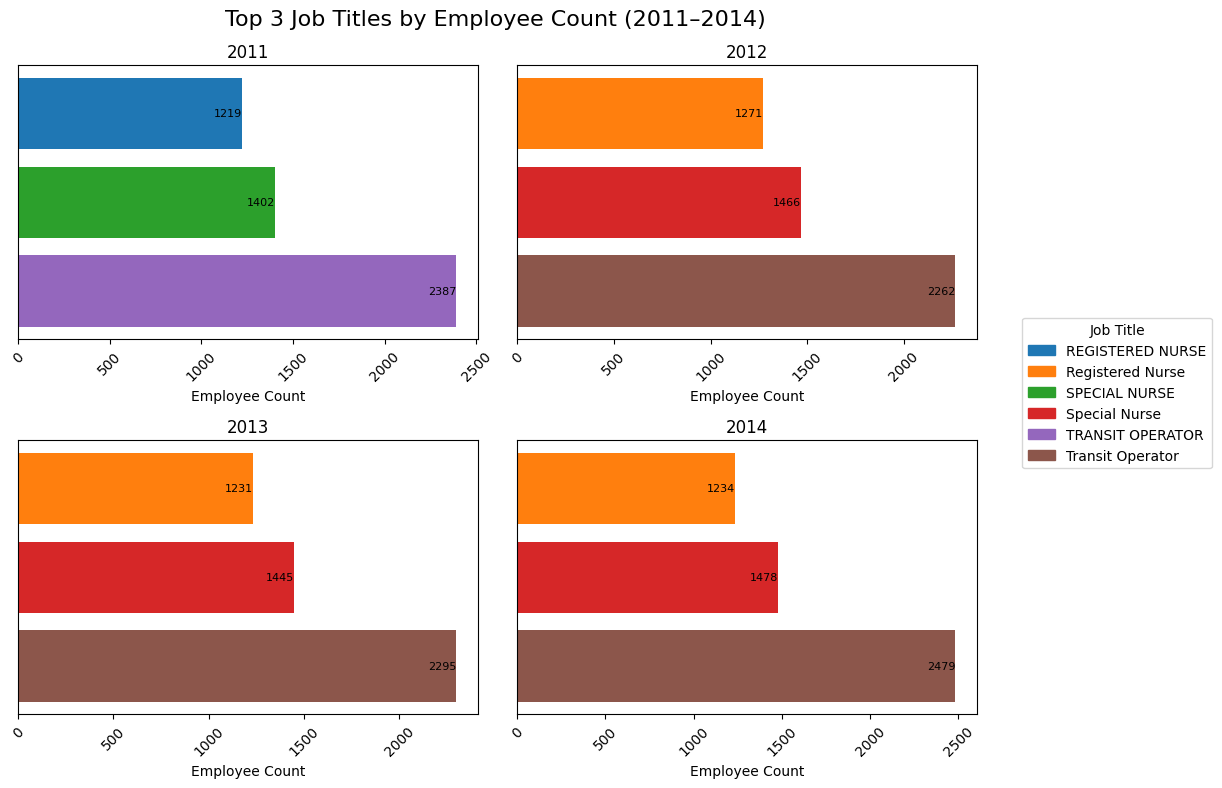

In [75]:
emp_count_years = sorted(top_jobs_emp_count["Year"].unique())
emp_count_jobs = sorted(top_jobs_emp_count["JobTitle"].unique())
emp_count_colors = plt.cm.tab10(range(len(jobs)))
emp_count_job_colors = dict(zip(emp_count_jobs, emp_count_colors))



fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, year in zip(axes, emp_count_years):
    temp = top_jobs_emp_count[top_jobs_emp_count["Year"] == year]
    bar_colors = [emp_count_job_colors[job] for job in temp["JobTitle"]]
    bars = ax.barh(temp["JobTitle"],
        temp["EmployeeCount"],
        color=bar_colors)
    ax.invert_yaxis()
    ax.set_title(str(year))
    ax.set_yticks([])
    ax.set_xlabel("Employee Count")
    ax.tick_params(axis='x', rotation=45)
    ax.invert_yaxis()
    ax.bar_label(bars, fmt="%.0f", fontsize=8, padding= -20)

handles = [
    Patch(color=emp_count_job_colors[job], label=job)
    for job in emp_count_jobs
]
fig.legend(
    handles=handles,
    title="Job Title",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)
plt.suptitle("Top 3 Job Titles by Employee Count (2011–2014)", fontsize=16)
plt.tight_layout()
plt.show()